Нийт хэрэглэгчдийн цуцлалтын хувь (Churn %): 18.55%


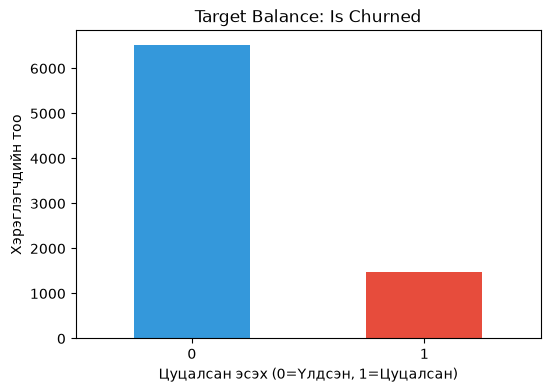

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df=pd.read_csv("../data/B_customer_churn_cleaned.csv")


churn_rate = df['is_churned'].mean() * 100
print(f"Нийт хэрэглэгчдийн цуцлалтын хувь (Churn %): {churn_rate:.2f}%")


plt.figure(figsize=(6, 4))
df['is_churned'].value_counts().plot(kind='bar', color=['#3498db', '#e74c3c'])
plt.title('Target Balance: Is Churned')
plt.xlabel('Цуцалсан эсэх (0=Үлдсэн, 1=Цуцалсан)')
plt.ylabel('Хэрэглэгчдийн тоо')
plt.xticks(rotation=0)
plt.show()

In [19]:
print("Датаны хэмжээ (Мөр, Багана):", df.shape)
print("\nis_churned баганын доторх утгууд:")
print(df['is_churned'].value_counts(dropna=False))

Датаны хэмжээ (Мөр, Багана): (8000, 10)

is_churned баганын доторх утгууд:
is_churned
0    6516
1    1484
Name: count, dtype: int64


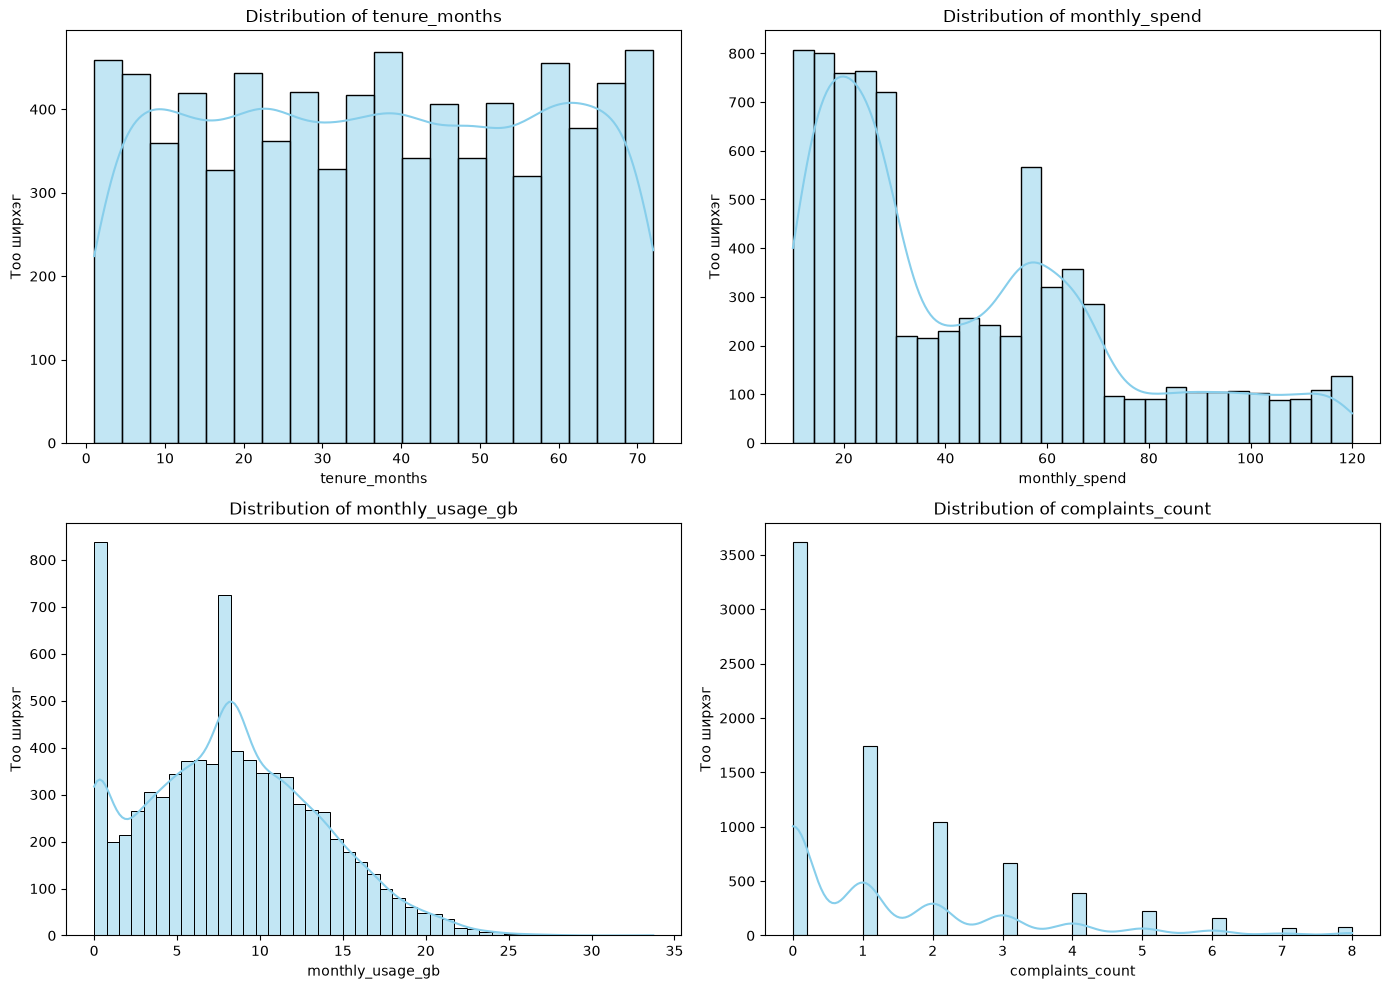

In [35]:
features = ['tenure_months', 'monthly_spend', 'monthly_usage_gb', 'complaints_count']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Тоо ширхэг')

plt.tight_layout()
plt.show()

In [ ]:

print("--- Гомдлын тоогоор ---")
print(df.groupby("complaints_count")["is_churned"].mean() * 100)

print("\n--- Багцын төрлөөр ---")
print(df.groupby("plan_type")["is_churned"].mean() * 100)

print("\n--- Хэрэглэсэн хугацаагаар ---")
df["tenure_bucket"] = pd.cut(df["tenure_months"], bins=[0, 6, 12, 24, 48, 72])
print(df.groupby("tenure_bucket", observed=True)["is_churned"].mean() * 100)


--- Гомдлын тоогоор ---
complaints_count
0    10.819037
1    14.687321
2    21.087786
3    26.656627
4    38.071066
5    42.358079
6    59.876543
7    62.121212
8    67.500000
Name: is_churned, dtype: float64

--- Багцын төрлөөр ---
plan_type
basic       20.995996
premium     13.476071
standard    17.839404
Name: is_churned, dtype: float64

--- Хэрэглэсэн хугацаагаар ---
tenure_bucket
(0, 6]      33.928571
(6, 12]     30.202312
(12, 24]    24.163569
(24, 48]    17.537747
(48, 72]     9.933530
Name: is_churned, dtype: float64


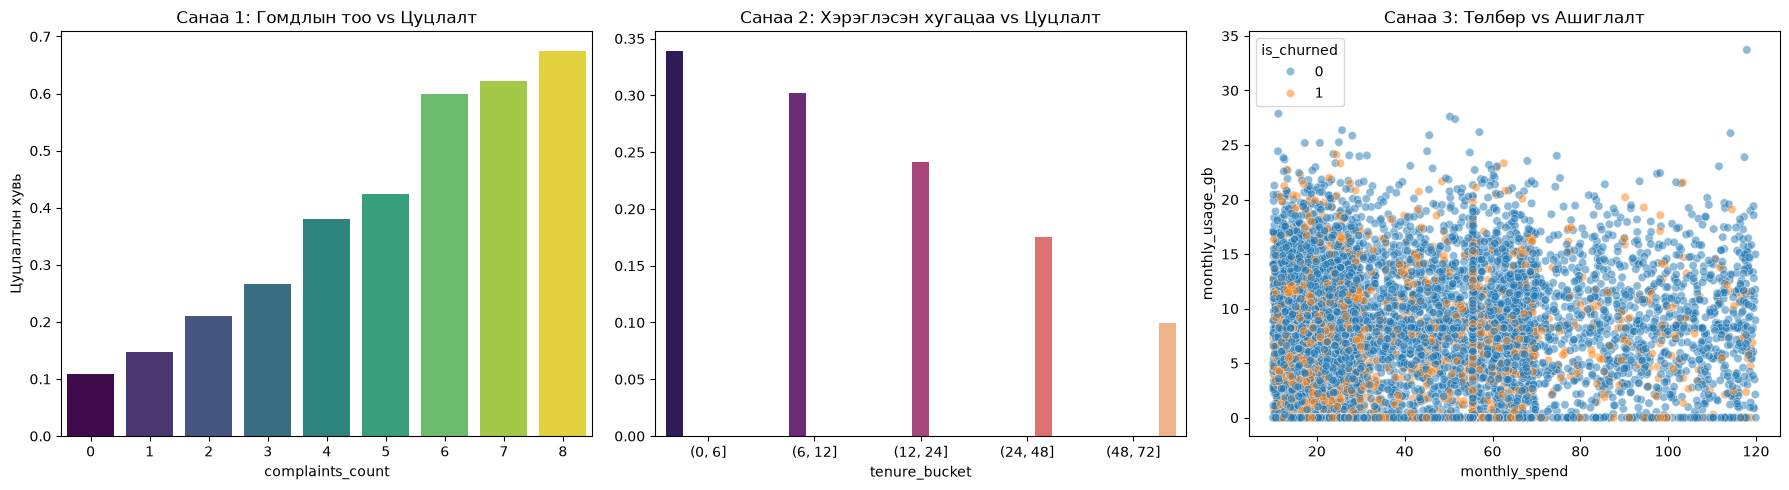

In [37]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))


sns.barplot(data=df, x='complaints_count', y='is_churned', errorbar=None, hue='complaints_count', palette='viridis', legend=False, ax=axes[0])
axes[0].set_title('Санаа 1: Гомдлын тоо vs Цуцлалт')
axes[0].set_ylabel('Цуцлалтын хувь')


sns.barplot(data=df, x='tenure_bucket', y='is_churned', errorbar=None, hue='tenure_bucket', palette='magma', legend=False, ax=axes[1])
axes[1].set_title('Санаа 2: Хэрэглэсэн хугацаа vs Цуцлалт')
axes[1].set_ylabel('')


sns.scatterplot(data=df, x='monthly_spend', y='monthly_usage_gb', hue='is_churned', alpha=0.5, ax=axes[2])
axes[2].set_title('Санаа 3: Төлбөр vs Ашиглалт')

plt.tight_layout()
plt.show()